# T14 · The butterfly and the PINN

Lorenz-63 is three coupled equations with three constants:

$$\dot x = \sigma (y - x), \qquad \dot y = x(\rho - z) - y, \qquad
\dot z = xy - \beta z,$$

and at $\sigma = 10$, $\rho = 28$, $\beta = 8/3$ it is chaotic. This notebook
asks one inverse question of it: given **40 noisy observations** of one
trajectory, recover the trajectory between them, the three constants, and a
forecast past the end.

It is the problem where a physics-informed network earns its name. A black
box can only interpolate the 40 points; the PINN also has to satisfy the law
everywhere in between, and the law carries the constants. The notebook shows:

1. the butterfly effect, and what it means for any forecast;
2. the PINN as a block diagram, and each term of its loss;
3. a vanilla PINN failing, and the recipe that fixes it;
4. the PINN against a tuned black box, and against classical shooting;
5. what the full study measured under noise and with less data.

In [1]:
import os
# no symbolic regression here, so skip the Julia bootstrap
os.environ.setdefault("PHYSPRIOR_NO_JULIA", "1")
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

torch.set_num_threads(2)
from IPython.display import Image, display
from physprior.config import get_settings
from physprior.lorenz import system as S, pinn as LP, classical as C, metrics as M
from physprior.lorenz import study as ST, doc as LD
from physprior.lorenz.figures import COLOR, LABEL
from physprior.io import load_json
FIG = get_settings().figures("lorenz")
cfgs = load_json("lorenz", "meta")["configs"]  # chosen on the tuning seeds

torch 2.11.0


## 1 · The butterfly effect

Start two trajectories $10^{-8}$ apart and integrate both with an 8th-order
method at a tolerance of $10^{-12}$. For a while they are the same curve.
Then the difference, which grows like $e^{\lambda_1 t}$ with the largest
Lyapunov exponent $\lambda_1 \approx 0.906$, reaches the size of the
attractor and the two are unrelated.

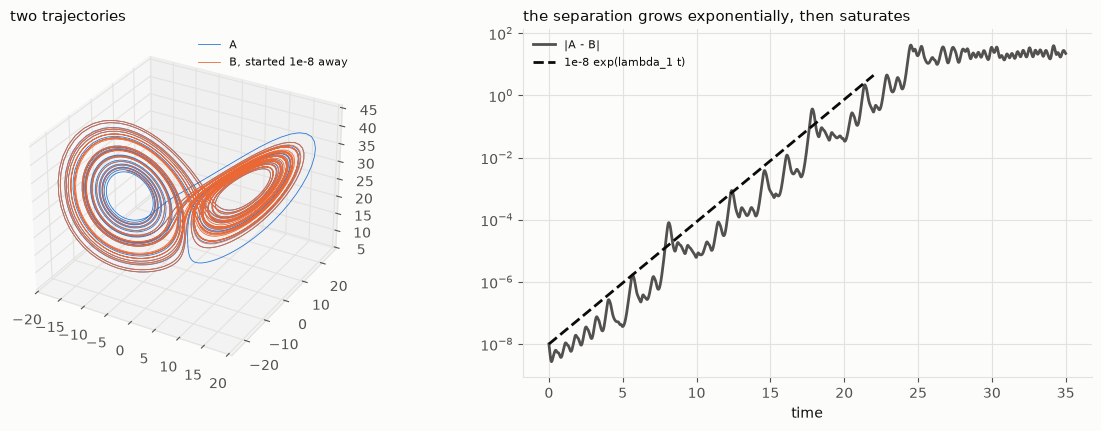

slope of log|A-B| on 1e-7 < d < 0.1: 0.844  (reference lambda_1 = 0.9056)


In [2]:
u0 = S.attractor_state(11)
t, a, b = S.separation(u0, delta=1e-8, t_end=35.0, n_out=3501)
d = np.linalg.norm(a - b, axis=1)
fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*a.T, lw=0.6, color=COLOR["ms"], label="A")
ax.plot(*b.T, lw=0.6, color=COLOR["pinn_polish"], label="B, started 1e-8 away")
ax.legend(fontsize=8); ax.set_title("two trajectories", loc="left")
ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(t, d, color=P.INK_2, label="|A - B|")
ax2.semilogy(t[:2200], 1e-8 * np.exp(S.LAMBDA1 * t[:2200]), "--", color=P.INK,
             label="1e-8 exp(lambda_1 t)")
ax2.set_xlabel("time"); ax2.legend(fontsize=8)
ax2.set_title("the separation grows exponentially, then saturates", loc="left")
plt.show()
print(f"slope of log|A-B| on 1e-7 < d < 0.1: {S.growth_rate(t, d, 1e-7, 1e-1):.3f}"
      f"  (reference lambda_1 = {S.LAMBDA1})")

One pair's slope wanders with the local stretching; the study averages the
log-separation over 24 pairs across the attractor. The practical meaning: a
forecast that starts with state error $e$ stays below an error threshold
$\epsilon$ for about $\ln(\epsilon/e)/\lambda_1$. Halving the error buys
$\ln 2 / \lambda_1 \approx 0.77$ time units, no matter the method. An
ensemble started in a ball of radius $10^{-5}$ spreads over the whole
attractor in about 15 time units:

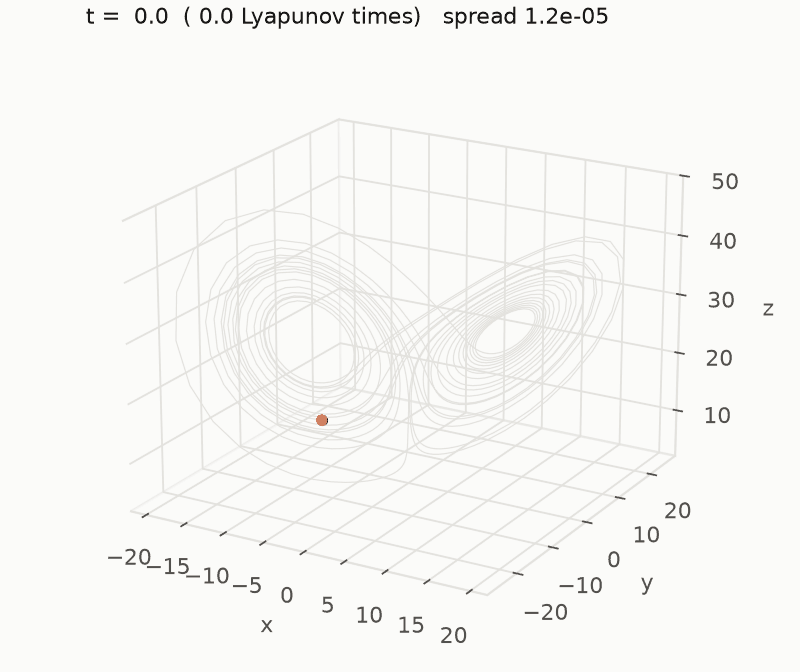

In [3]:
display(Image(filename=str(FIG / "butterfly.gif")))

## 2 · The data

The fits below use reporting seed 23. `S.observe(seed)` puts a random point on the attractor, integrates three time
units (about 2.7 Lyapunov times), and samples 40 random times with Gaussian
noise of 5 % of each component's spread. The same seed gives the same
trajectory at every noise level and every budget.

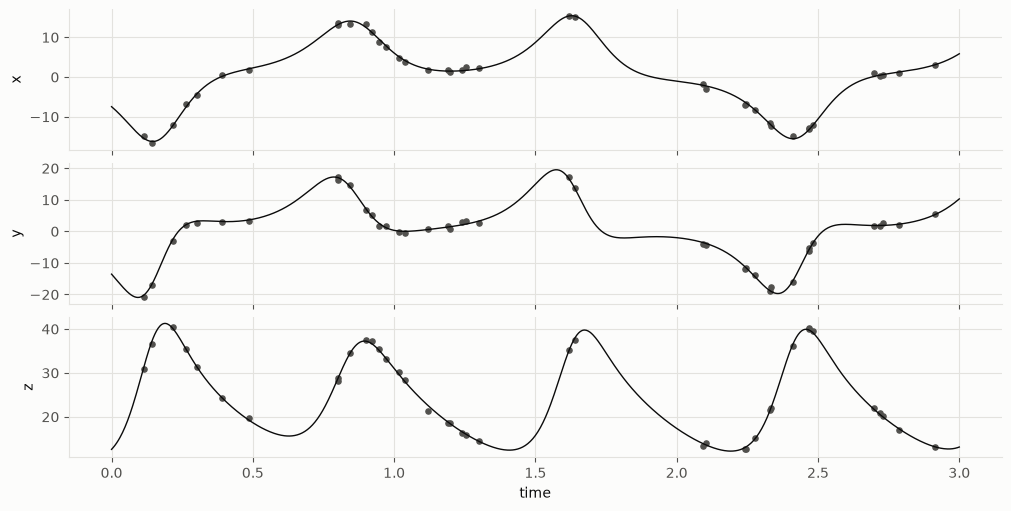

start of every fit: sigma, rho, beta = [ 5. 15.  1.]  truth: [10.     28.      2.6667]


In [4]:
SEED = 23  # a reporting seed on which the classical fit fails
obs = S.observe(SEED, n_obs=40, noise=0.05)
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(obs.t_dense, obs.u_dense[:, k], color=P.INK, lw=1)
    ax.scatter(obs.t_obs, obs.y_obs[:, k], s=14, color=P.INK_2)
    ax.set_ylabel("xyz"[k])
axes[-1].set_xlabel("time"); plt.show()
print("start of every fit: sigma, rho, beta =", S.THETA_INIT, " truth:", S.THETA_TRUE.round(4))

## 3 · The PINN, drawn

The network maps time to state. Two losses act on it:

* $L_{data}$: the standardised squared error at the 40 observations;
* $L_{phys}$: the squared residual $\dot u - f(u; \sigma, \rho, \beta)$ at 256
  collocation times, redrawn every step, with the three constants trained
  alongside the weights.

$L = L_{data} + w(k)\,L_{phys}$, where $w(k)$ is 0 for a warm-up and then
ramped up. The time derivative is carried through the network in
**forward mode**: for a scalar input each layer's tangent is one vector,
$\dot h' = (1 - h'^2) \odot W \dot h$, so the derivative costs one extra
matrix product per layer in the same pass.

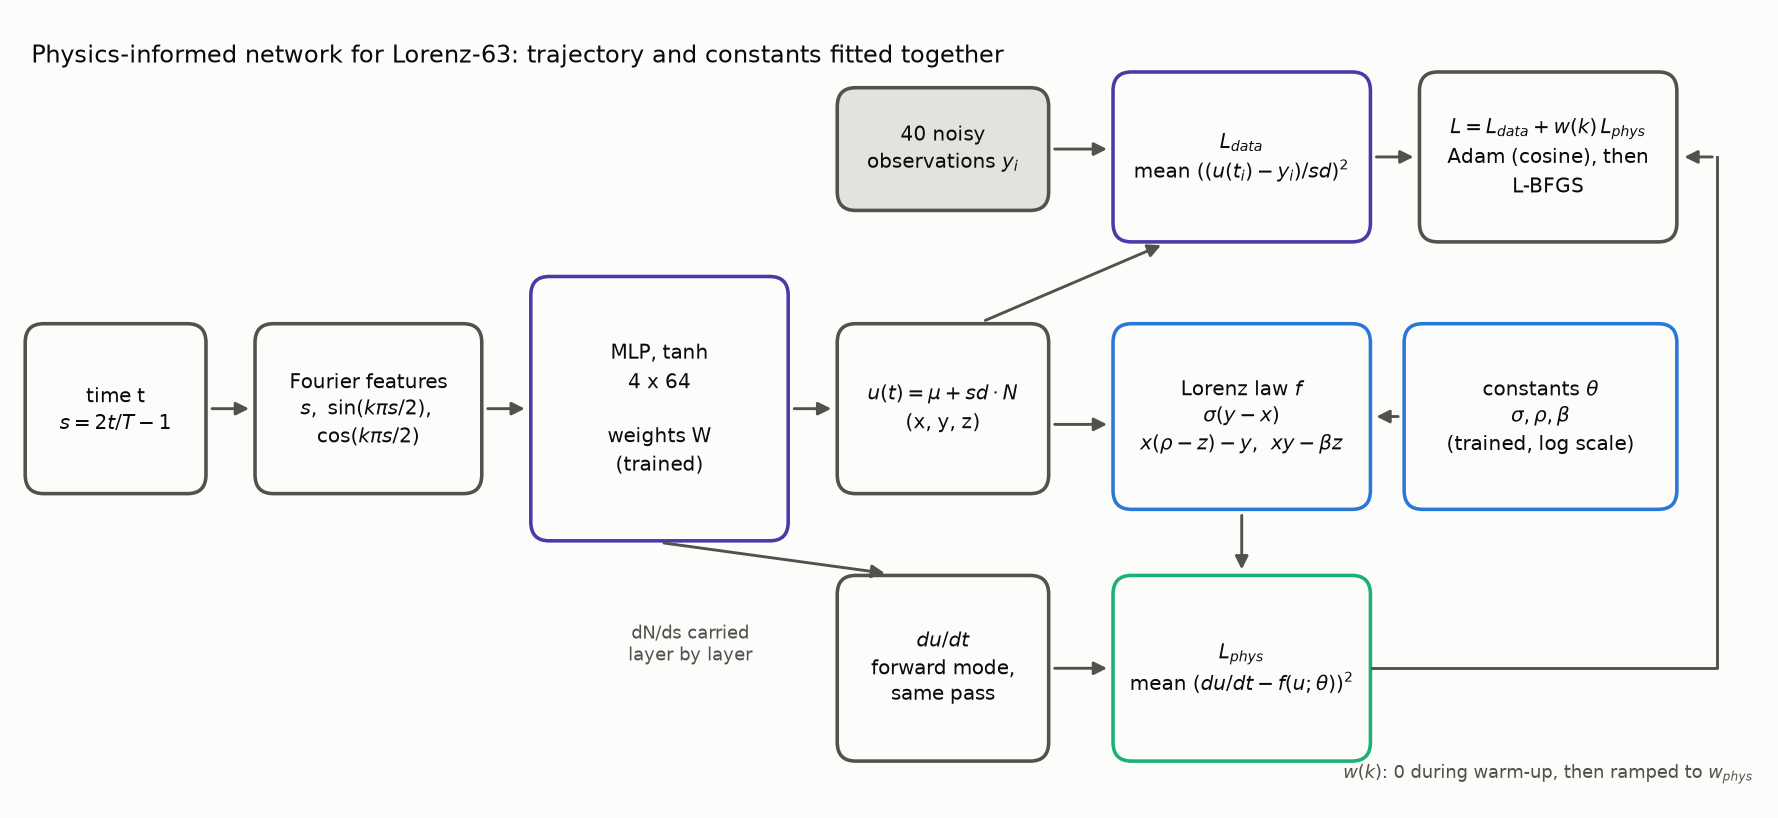

In [5]:
display(Image(filename=str(FIG / "block_diagram.png")))

Three ways to get $du/dt$ from the same network, which must agree to
rounding: the hand-written forward mode used in training, reverse-mode
`torch.autograd.grad` (one backward pass per output component, with the graph
kept for the second derivative the optimiser needs), and `torch.func.jvp`,
PyTorch's functional forward mode.

In [6]:
# the hand-written forward mode against reverse-mode autograd and torch.func.jvp
net = LP.LorenzNet(64, 4, fourier=8)
s = torch.linspace(-1, 1, 101)[:, None]
d_fwd = LP.derivative_fn(net, "forward")(s)[1]
d_rev = LP.derivative_fn(net, "autograd")(s)[1]
d_jvp = LP.derivative_fn(net, "jvp")(s)[1]
print("max |forward - autograd| =", float((d_fwd - d_rev).abs().max()))
print("max |jvp - autograd|     =", float((d_jvp - d_rev).abs().max()))

max |forward - autograd| = 1.1102230246251565e-15
max |jvp - autograd|     = 1.1102230246251565e-15


## 4 · A vanilla PINN fails

Put the physics term on from the first step, with a constant learning rate
and Adam only. At initialisation the residual term is about $10^5$ times the
data term. The fastest way down is to satisfy the law, with whatever
constants, on a trajectory that ignores the data: the trivial solution.

In [7]:
vanilla = LP.PinnConfig(fourier=0, schedule="constant", warmup=0, ramp=0,
                        resample=False, lbfgs=0, steps=2500,
                        w_phys=cfgs["pinn"]["w_phys"])
f_van = LP.fit(obs, vanilla, seed=SEED)
print("vanilla: trajectory error", round(M.nrmse(f_van.predict(obs.t_dense), obs.u_dense), 3),
      " constants", f_van.theta.round(2))

vanilla: trajectory error 0.619  constants [ 5.06 26.91  1.58]


## 5 · The recipe, and a black box beside it

The recipe adds, in order: a data-only warm-up and a ramp of the physics
weight; a cosine learning-rate decay and fresh collocation times each step;
an L-BFGS finish; Fourier features of time. The black box is the same kind of
network, with the size chosen on the tuning seeds, trained on $L_{data}$
alone. Short budgets here; the study trains 6000 Adam steps and 1000 L-BFGS
iterations.

In [8]:
pinn_cfg = LP.PinnConfig(**{**cfgs["pinn"], "steps": 3000, "warmup": 600,
                            "ramp": 600, "lbfgs": 300})
nn_cfg = LP.PinnConfig(**{**cfgs["nn"], "steps": 3000})
f_pinn = LP.fit(obs, pinn_cfg, seed=SEED)
f_nn = LP.fit(obs, nn_cfg, seed=SEED)
for name, f in (("black box", f_nn), ("PINN", f_pinn)):
    print(f"{name:10s} trajectory error {M.nrmse(f.predict(obs.t_dense), obs.u_dense):.4f}"
          f"   du/dt error {M.nrmse(f.derivative(obs.t_dense), obs.du_dense):.4f}"
          f"   {f.seconds:.0f} s")
print("PINN constants:", f_pinn.theta.round(3), " truth:", S.THETA_TRUE.round(3))

black box  trajectory error 0.2821   du/dt error 0.4182   2 s
PINN       trajectory error 0.0129   du/dt error 0.0225   11 s
PINN constants: [10.134 28.016  2.668]  truth: [10.    28.     2.667]


Between the observations the black box has only the data to go on, and on a
chaotic trajectory the data are not enough: it smooths over the fast turns.
The PINN is held to the law everywhere, so it follows the turns the
observations only sample.

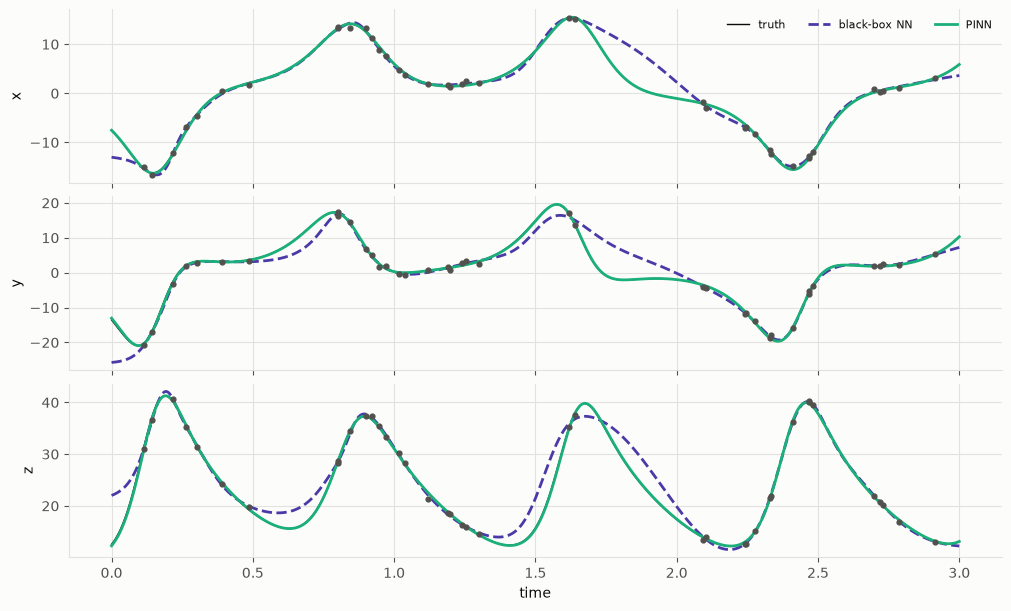

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(obs.t_dense, obs.u_dense[:, k], color=P.INK, lw=1, label="truth")
    ax.plot(obs.t_dense, f_nn.predict(obs.t_dense)[:, k], "--", color=COLOR["nn"], label=LABEL["nn"])
    ax.plot(obs.t_dense, f_pinn.predict(obs.t_dense)[:, k], color=COLOR["pinn"], label=LABEL["pinn"])
    ax.scatter(obs.t_obs, obs.y_obs[:, k], s=12, color=P.INK_2, zorder=3)
    ax.set_ylabel("xyz"[k])
axes[0].legend(fontsize=8, ncol=3); axes[-1].set_xlabel("time"); plt.show()

### The loss, term by term

`fit` records every term every 25 steps. The data term falls during the
warm-up, rises a little when the physics weight comes on (the network gives
up fitting the noise), and settles near the noise floor $0.05^2$. The
residual of each equation falls, fastest under L-BFGS, and the constants
walk from their wrong start to the truth.

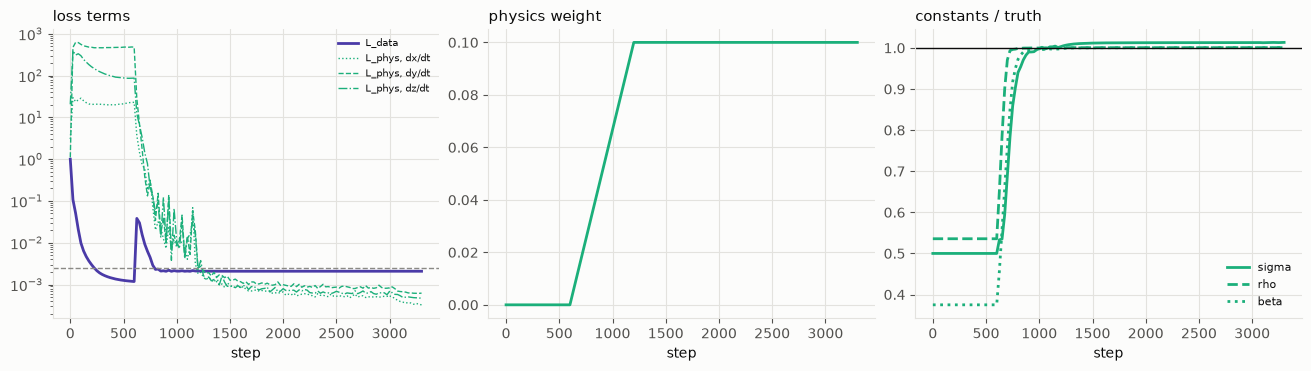

In [10]:
h = {k: np.asarray(v) for k, v in f_pinn.history.items()}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].semilogy(h["step"], h["data"], color=COLOR["nn"], label="L_data")
for comp, ls in zip("xyz", (":", "--", "-.")):
    axes[0].semilogy(h["step"], h["phys_" + comp], ls, color=COLOR["pinn"], lw=1,
                     label=f"L_phys, d{comp}/dt")
axes[0].axhline(0.05 ** 2, color=P.INK_MUTED, lw=1, ls="--"); axes[0].legend(fontsize=7)
axes[0].set_title("loss terms", loc="left")
axes[1].plot(h["step"], h["w"], color=COLOR["pinn"]); axes[1].set_title("physics weight", loc="left")
for n, tv, ls in zip(S.THETA_NAMES, S.THETA_TRUE, ("-", "--", ":")):
    axes[2].plot(h["step"], h[n] / tv, ls, color=COLOR["pinn"], label=n)
axes[2].axhline(1, color=P.INK, lw=1); axes[2].legend(fontsize=8)
axes[2].set_title("constants / truth", loc="left")
for ax in axes: ax.set_xlabel("step")
plt.show()

## 6 · Against classical fitting

The classical inverse problem integrates the law from a guessed state and
guessed constants and moves all six by least squares (**single shooting**).
On a chaotic system over 2.7 Lyapunov times its residual surface is rugged,
and from the same wrong start as the PINN it can land in a wrong minimum:
on this seed it does, and in the study it does on two of the three reporting
seeds.
**Multiple shooting** cuts the window into segments, each with its own
initial state, and makes continuity a residual: every segment is short
compared with the Lyapunov time, and the surface is smooth enough again.

In [11]:
sh = C.single_shooting(obs, max_nfev=150)
ms = C.multiple_shooting(obs, n_seg=cfgs["ms"]["n_seg"], max_nfev=150)
pol = C.polish(obs, f_pinn.theta, f_pinn.predict(np.array([0.0]))[0], "pinn_polish")
for name, th in (("single shooting", sh.theta), ("multiple shooting", ms.theta),
                 ("PINN", f_pinn.theta), ("PINN, then shooting", pol.theta),
                 ("black box, then regression", C.regress_theta(
                     f_nn.predict(obs.t_dense), f_nn.derivative(obs.t_dense)))):
    print(f"{name:28s} {np.round(th, 3)}   mean error {M.theta_errors(th)['err_theta']:.2%}")

single shooting              [ 9.688 14.698  0.183]   mean error 47.92%
multiple shooting            [10.088 28.007  2.669]   mean error 0.33%
PINN                         [10.134 28.016  2.668]   mean error 0.48%
PINN, then shooting          [10.01  28.007  2.669]   mean error 0.07%
black box, then regression   [ 8.766 29.141  3.117]   mean error 11.09%


A well-built classical fit is as good as the PINN on the constants; the
PINN's own contribution is that it needs no segment count, gives a smooth
trajectory and derivative, and hands single shooting a start inside the
basin. The study finds the same on the reporting seeds.

## 7 · What the full study measured

Everything below is read from `results/lorenz/`, produced by
`physprior lorenz` on the reporting seeds 11 / 23 / 42 with the full
budgets.

In [12]:
f = LD.findings()
print(f"trajectory error: black box {f['state_nn']:.3f}, PINN {f['state_pinn']:.4f} "
      f"(factor {f['state_ratio']:.1f}, PINN better on {f['wins_state']}/{f['n_seeds']} seeds)")
print(f"constants: PINN {f['theta_pinn']:.2%}, multiple shooting {f['theta_ms']:.2%}, "
      f"single shooting {f['theta_shooting']:.0%}, black box + regression {f['theta_nn_regress']:.2%}")
LD.main_table().round(4)

trajectory error: black box 0.104, PINN 0.0127 (factor 8.1, PINN better on 3/3 seeds)
constants: PINN 0.52%, multiple shooting 0.37%, single shooting 48%, black box + regression 2.33%


,method,trajectory error,du/dt error,sigma error,rho error,beta error,"worst seed, constants",valid forecast (Lyapunov times)
0,black-box NN,0.1036,0.2581,NaN,NaN,NaN,NaN,0.0362
1,"NN, then regression",NaN,NaN,0.0599,0.0074,0.0098,0.0889,0.0996
2,finite differences,NaN,NaN,0.0940,0.0133,0.0863,0.3784,NaN
3,single shooting,0.9270,0.9418,0.0312,0.1022,0.8652,1.2095,0.0000
4,multiple shooting,0.0122,0.0216,0.0070,0.0017,0.0027,0.0040,2.1191
5,PINN,0.0127,0.0223,0.0106,0.0007,0.0031,0.0053,2.3183
6,"PINN, then shooting",0.0108,0.0178,0.0051,0.0020,0.0025,0.0039,2.2549


### Noise

The black box cannot interpolate the trajectory between 40 points even when
they are exact, so its error hardly moves with the noise. The PINN's error
scales with the noise: the law fills in between the points and averages the
noise out. The factor between them is largest on clean data.

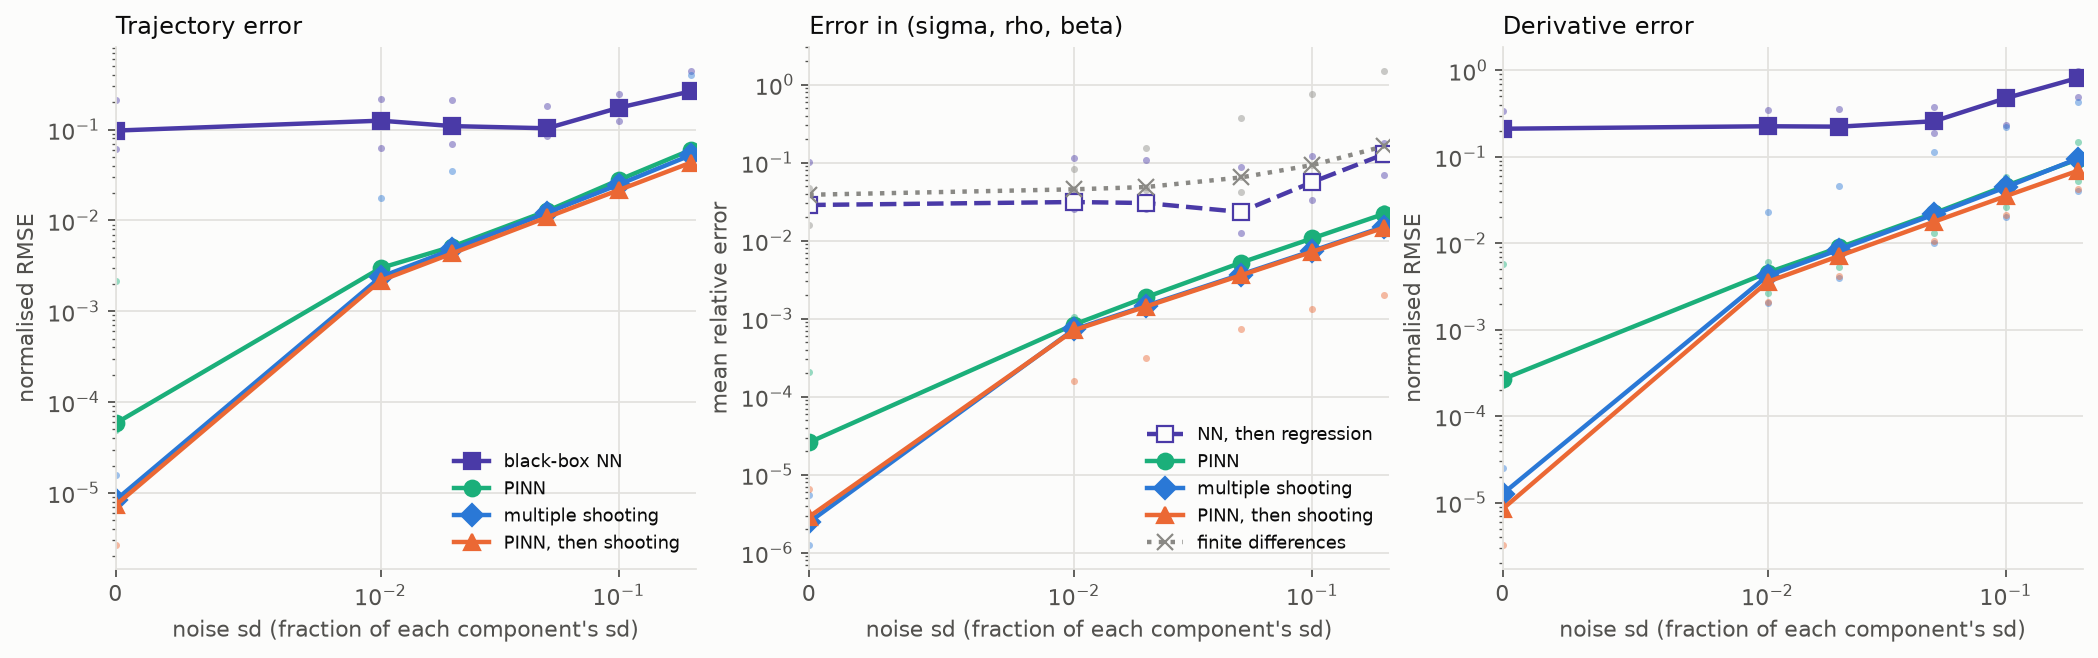

In [13]:
display(Image(filename=str(FIG / "noise.png")))

### Data budget

Fewer points widen the gap until, at 10 points, neither network can draw
the trajectory. The constants are another matter: the PINN still recovers
them, where multiple shooting and the black box followed by regression do
not.

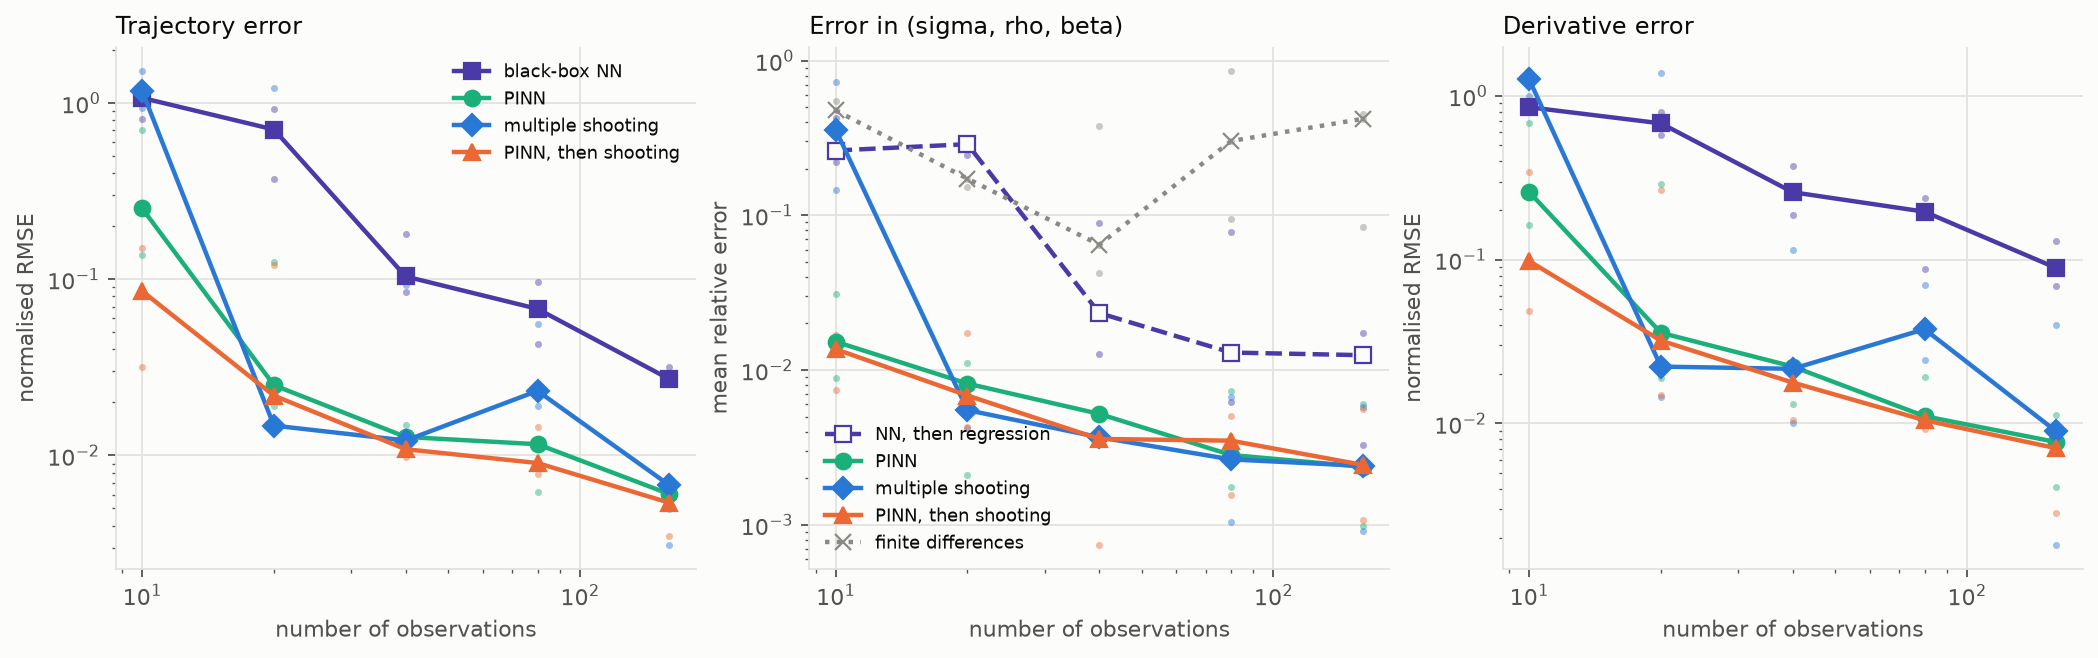

In [14]:
display(Image(filename=str(FIG / "budget.png")))

### The optimisation ladder

Each rung adds one thing to the one before; the last two try the two
loss-weighting schemes from the literature instead.

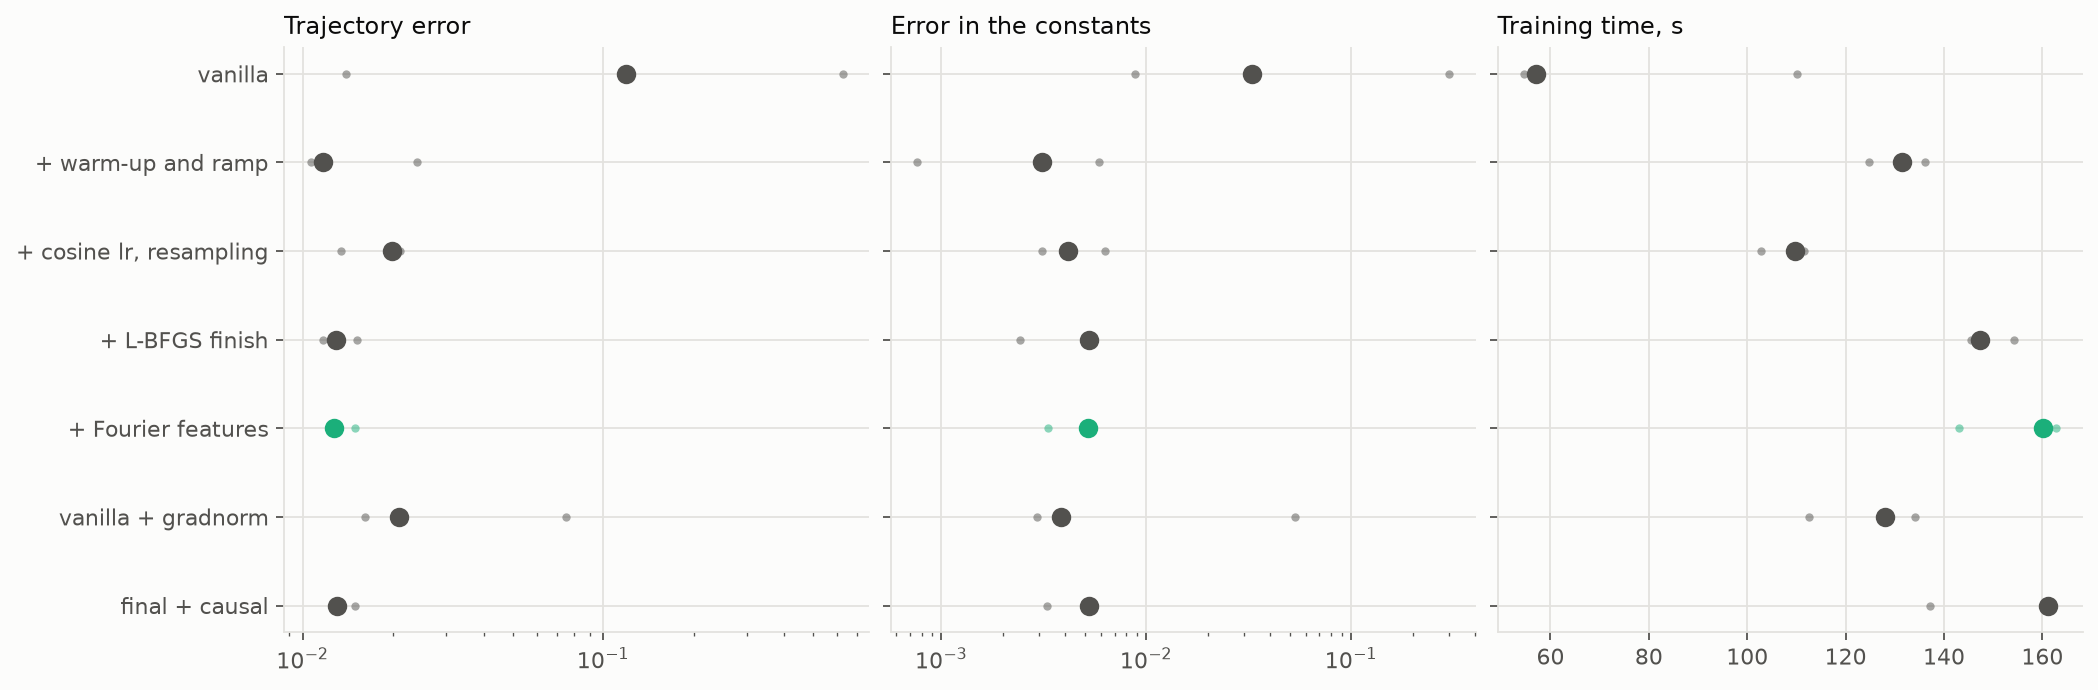

,recipe,trajectory error,constants error,"worst seed, trajectory",seconds
0,vanilla,0.1192,0.0328,0.6256,56.9744
1,+ warm-up and ramp,0.0116,0.0031,0.0239,131.4007
2,"+ cosine lr, resampling",0.0198,0.0042,0.0210,109.7668
3,+ L-BFGS finish,0.0129,0.0053,0.0151,147.3392
4,+ Fourier features,0.0127,0.0052,0.0149,160.1849
5,vanilla + gradnorm,0.0210,0.0039,0.0754,128.1058
6,final + causal,0.0130,0.0053,0.0149,161.0815


In [15]:
display(Image(filename=str(FIG / "ladder.png")))
LD.ladder_table().round(4)

### Forecasting

With the constants recovered, the law itself is the forecaster: integrate it
from the fitted end state. The black box has nothing to integrate and its
extrapolation fails at once. Every forecast still dies at the Lyapunov rate;
the right panel shows how long a forecast from the *exact* state lasts as a
function of the error in the constants, with the fitted methods on top.

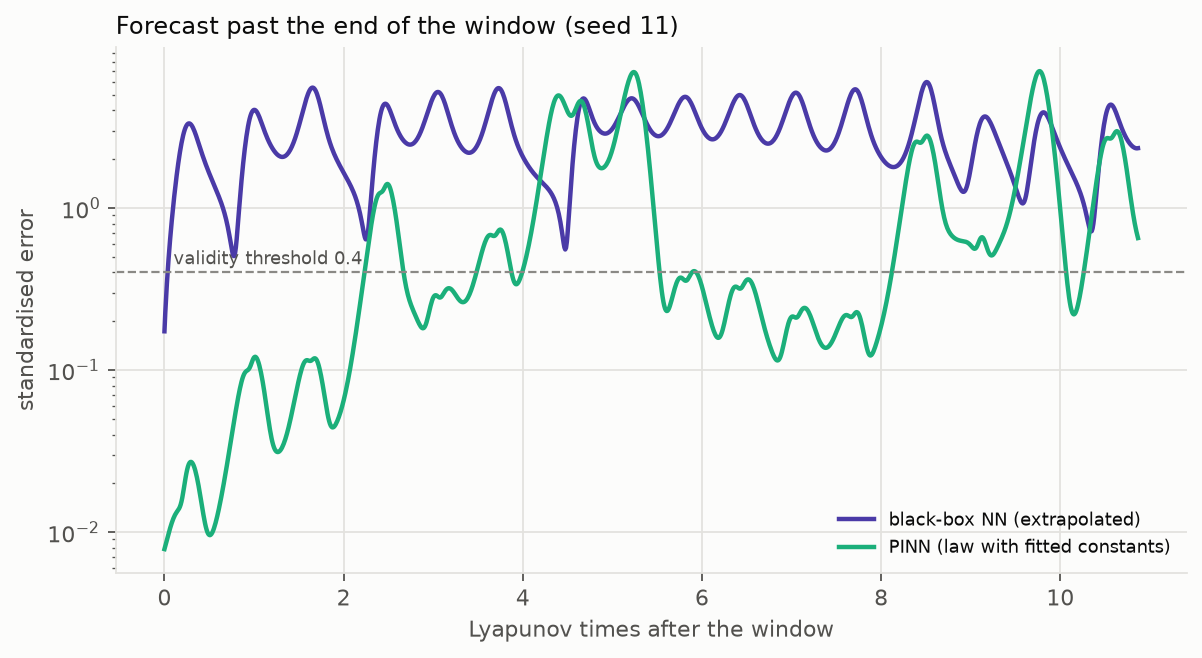

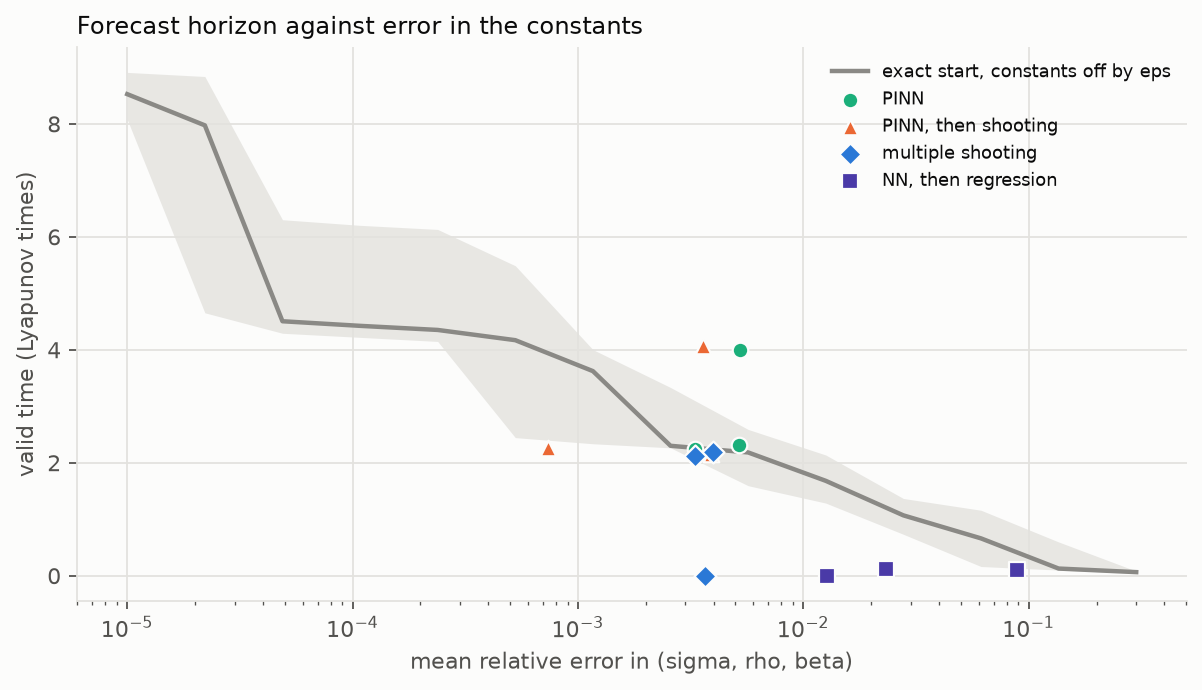

In [16]:
display(Image(filename=str(FIG / "forecast.png")))
display(Image(filename=str(FIG / "horizon.png")))

## Summary

* On a chaotic inverse problem with 40 noisy points, the PINN reconstructs
  the trajectory and its derivative several times better than a tuned black
  box, and recovers the constants from a start that is wrong by a factor of
  two.
* The PINN only works with its training recipe. The vanilla version
  collapses onto a law-satisfying trajectory that ignores the data; a data
  warm-up with a ramped physics weight and an L-BFGS finish are the two
  pieces that matter most.
* It does not beat a well-built classical fit: multiple shooting recovers the
  constants as well. Single shooting, the textbook route, fails.
* Nothing beats the butterfly effect. A forecast lasts a few Lyapunov times,
  set by how accurate the end state and the constants are.